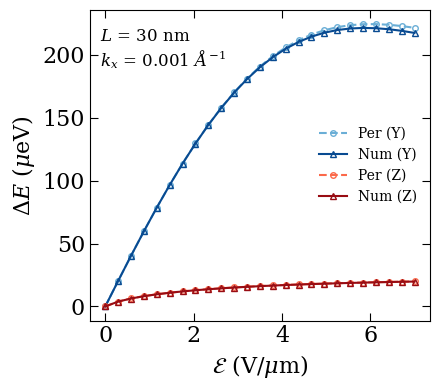

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
#                      GLOBAL SETTINGS
# ==============================================================

plt.rcParams.update({
    "figure.figsize": [4.5, 4],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

# ==============================================================
#                      SPLITTING PLOT
# ==============================================================
N = 100
L = 300
kx = 0.001

emax = 0.7e-3*1e4

datay_pb = np.loadtxt(f"Pymablock_Y_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
datay_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{(emax):.2f}_y.dat", skiprows=1)

Efield = datay_pb[:, 0]
alpha_y = datay_pb[:, 1]
split_pb_2nd_y = datay_pb[:, 2]
split_num_y = datay_num[:, 3]



dataz_pb = np.loadtxt(f"Pymablock_Z_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
dataz_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{(emax):.2f}_z.dat", skiprows=1)

Efield = dataz_pb[:, 0]
alpha_z = dataz_pb[:, 1]
split_pb_2nd_z = dataz_pb[:, 2]
split_num_z = dataz_num[:, 3]

# Color maps
cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds

# Pick 3 shades (light → dark)
blue_colors = cmap_blue([0.5, 0.7, 0.9])
red_colors  = cmap_red([0.5, 0.7, 0.9])

# ==============================================================
#                      PLOT
# ==============================================================

fig, ax = plt.subplots()

# Y = blue, Z = red

# Y direction (Blues)
ax.plot(Efield, split_pb_2nd_y, 'o--', color=blue_colors[0],
        label="Per (Y)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_num_y, '^-', color=blue_colors[2],
        label="Num (Y)", markersize=4, markerfacecolor='None')


# Z direction (Reds)
ax.plot(Efield, split_pb_2nd_z, 'o--', color=red_colors[0],
        label="Per (Z)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_num_z, '^-', color=red_colors[2],
        label="Num (Z)", markersize=4, markerfacecolor='None')

ax.legend(frameon=False, ncol=1, fontsize = 10)
ax.text(0.03,0.82,f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax.transAxes, fontsize = 12)
ax.text(0.03,0.9,f"$L$ = {int(L/10)} nm", transform=ax.transAxes,fontsize = 12)


# Labels
ax.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize = 16)
ax.set_ylabel(r"$\Delta E$ ($\mu$eV)", fontsize = 16)
ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=16)

plt.tight_layout()
plt.savefig(f"splitting_plot_N{N}_L{L}_kx{kx}.png",dpi=300)
plt.savefig(f"splitting_plot_N{N}_L{L}_kx{kx}.pdf",dpi=300)
plt.show()

# print("-"*40)
# print("E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)")
# print("-"*40)
# for i in range(1,len(Efield)):
#     print(Efield[i].round(3), split_num_y[i].round(3))#, (split_num_y[i]/(Efield[i]*kx*10)).round(3))

# print("-"*40)
# print("E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)")
# print("-"*40)
# for i in range(1,len(Efield)):
#     print(Efield[i].round(3), split_num_z[i].round(3))#, (split_num_z[i]/(Efield[i]*kx*10)).round(3))

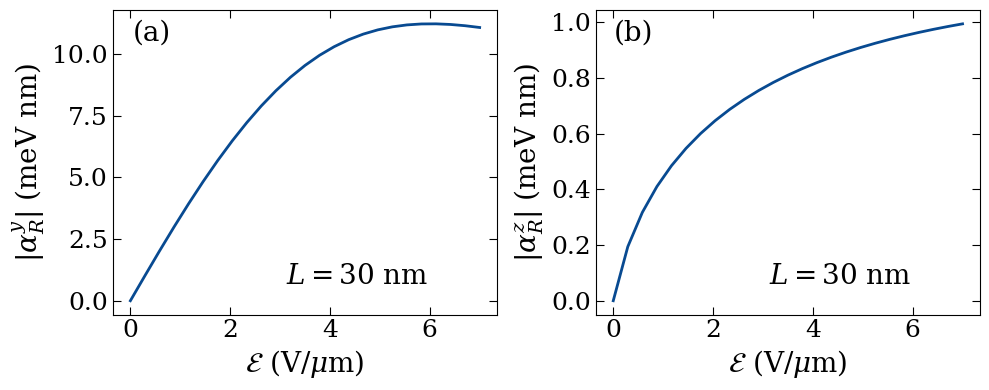

In [2]:
# ==============================================================
#                 UNIT CONVERSION
# ==============================================================

# Convert Rashba coefficients from eV Å to meV nm
#
# 1 eV Å = 100 meV nm

alpha_y_plot = 100.0 * np.asarray(alpha_y)
alpha_z_plot = 100.0 * np.asarray(alpha_z)


# ==============================================================
#                      PLOT
# ==============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4),
    sharex=True
)

ax_y, ax_z = axes


# --------------------------------------------------------------
# Y direction
# --------------------------------------------------------------

ax_y.plot(
    Efield,
    alpha_y_plot,
    '-',
    color=blue_colors[2],
    lw = 2,
    # markersize=7,
    # markerfacecolor='None'
)

# ax_y.set_title(
#     r"$\mathcal{E}\parallel y$",
#     fontsize=14
# )

ax_y.text(
    0.45,
    0.1,
    rf"$L={int(L/10)}$ nm",
    transform=ax_y.transAxes,
    fontsize = 20
)

# ax_y.text(
#     0.45,
#     0.1,
#     rf"$k_x={kx}\ \mathrm{{\AA}}^{{-1}}$",
#     transform=ax_y.transAxes,
#     fontsize = 20
# )

ax_y.set_xlabel(
    r"$\mathcal{E}$ (V/$\mu$m)",
    fontsize = 20
)

ax_y.set_ylabel(
    r"$|\alpha_R^y|$ (meV nm)",
    fontsize = 20
)

ax_y.tick_params(
    direction='in',
    length=6,
    width=0.8,
    top=True,
    right=True,
    labelsize=18
)

ax_y.text(
    0.15,
    0.9,
    "(a)",
    transform=ax_y.transAxes,
    fontsize = 20,
    ha="right"
)


# --------------------------------------------------------------
# Z direction
# --------------------------------------------------------------

ax_z.plot(
    Efield,
    alpha_z_plot,
    '-',
    color=blue_colors[2],
    lw = 2,
    # markersize=7,
    # markerfacecolor='None'
)

# ax_z.set_title(
#     r"$\mathcal{E}\parallel z$",
#     fontsize=14
# )

ax_z.text(
    0.45,
    0.1,
    rf"$L={int(L/10)}$ nm",
    transform=ax_z.transAxes,
    fontsize = 20
)

# ax_z.text(
#     0.45,
#     0.1,
#     rf"$k_x={kx}\ \mathrm{{\AA}}^{{-1}}$",
#     transform=ax_z.transAxes,
#     fontsize = 20
# )

ax_z.set_xlabel(
    r"$\mathcal{E}$ (V/$\mu$m)",
    fontsize = 20
)

ax_z.set_ylabel(
    r"$|\alpha_R^z|$ (meV nm)",
    fontsize = 20
)

ax_z.tick_params(
    direction='in',
    length=6,
    width=0.8,
    top=True,
    right=True,
    labelsize=18
)

ax_z.text(
    0.15,
    0.9,
    "(b)",
    transform=ax_z.transAxes,
    fontsize = 20,
    ha="right"
)


# ==============================================================
#                 LAYOUT AND SAVING
# ==============================================================

plt.tight_layout()

plt.savefig(
    f"alpha_plot_1x2_N{N}_L{L}_kx{kx}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    f"alpha_linear_k.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    f"alpha_linear_k.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()